In [5]:
from gensim.models import word2vec
from tensorflow.keras import preprocessing
import matplotlib.pyplot as plt
from pyvi import ViTokenizer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cleandt
from embedding import PatchEmbedding, MeanVectorizer

## Import and normalize data

In [6]:
# Đọc dữ liệu
news = pd.read_csv('../data/data_processed/train_no_label.csv') 
print(news.shape)
print(news.info())
print(news.head())


(8898, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8898 entries, 0 to 8897
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   comment    8898 non-null   object
 1   n_star     8898 non-null   int64 
 2   date_time  8898 non-null   object
dtypes: int64(1), object(2)
memory usage: 208.7+ KB
None
                                             comment  n_star   date_time
0  pin kém còn miễn chê mua 832019 tình_trạng pin...       5  14/09/2019
1  sao gọi điện_thoại màn_hình chấm nhỏ nháy gần ...       3  17/08/2020
2  mọi người cập_nhật phần_mềm nó bớt tốn pin mìn...       3  29/02/2020
3  mới mua sài 1 tháng thấy pin trâu sài bao mượt...       5    4/6/2020
4  xài tốt mượt pin trâu bạn độ sáng đủ nhân_viên...       5  20/06/2019


In [7]:
# Kiểm tra và xử lý giá trị thiếu
print(news.isna().sum())
news.dropna(axis=0, inplace=True)
news.reset_index(inplace=True)
news.drop(columns=['index'], axis=1, inplace=True)

comment      0
n_star       0
date_time    0
dtype: int64


In [8]:
# Loại bỏ từ dừng
news['comment'] = news['comment'].apply(lambda x: cleandt.remove_stopword(x, '../data/data_stopword/vietnamese-stopwords.txt'))

## Create word embedding model from Word2Vec

In [9]:
sequences = news['comment'].to_list()
input_gensim = []

for sen in sequences:
  input_gensim.append(sen.split())

In [10]:
model = word2vec.Word2Vec(input_gensim, vector_size=128, window=5, min_count=0, workers=4, sg=1)
model.save("../model/word2vec_no_label.model")

In [11]:
model = word2vec.Word2Vec.load("../model/word2vec_no_label.model")

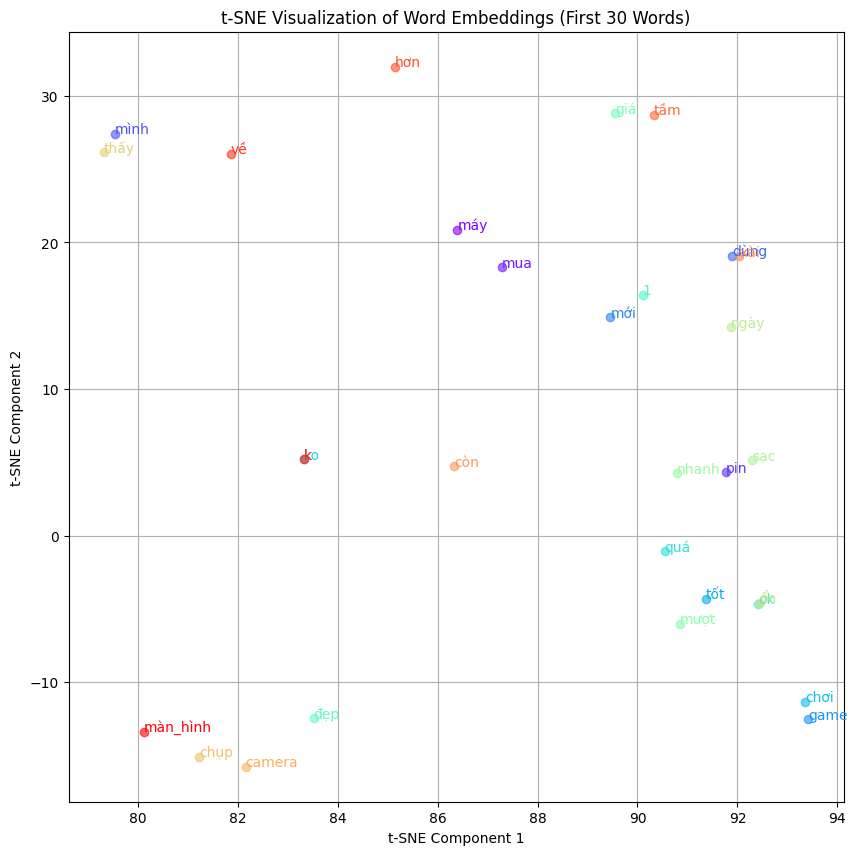

In [12]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Lấy các từ và vector từ mô hình
words = list(model.wv.index_to_key)
word_vectors = model.wv[words]

# Giảm chiều dữ liệu xuống 2 chiều bằng t-SNE
tsne = TSNE(n_components=2, random_state=42)
word_vecs_2d = tsne.fit_transform(word_vectors)

# Trực quan hóa các vectơ từ
plt.figure(figsize=(10, 10))
num_words = 30
# Màu cho mỗi từ
colors = plt.cm.rainbow(np.linspace(0, 1, num_words))

# Vẽ các điểm dữ liệu (từ) với màu khác nhau
for i, word in enumerate(words[:num_words]):  
    plt.scatter(word_vecs_2d[i, 0], word_vecs_2d[i, 1], marker='o', color=colors[i], alpha=0.6)
    plt.annotate(word, xy=(word_vecs_2d[i, 0], word_vecs_2d[i, 1]), fontsize=10, color=colors[i])

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE Visualization of Word Embeddings (First 30 Words)')
plt.grid(True)
plt.show()


## Find similar texts by Cosine measure

In [13]:
question = '''
mình mua máy samsung a20s 4 ngày nói_chung máy xài ổn trong tầm giá pin trâu chơi game xài 2 đến 3 ngày còn chơi game liên_quân tầm 1 ngày chụp hình đẹp máy mượt lâu_lâu cảm_biến vân tay nhạy ngón tay hơi ướt xíu máy nhận vân tay luôn ốp lưng xài hơi xót xíu mình làm trong môi_trường chăn_nuôi bụi cám kia
'''

In [14]:
pemb = PatchEmbedding(word_model=model, stopword_path="../data/data_stopword/vietnamese-stopwords.txt")

question_embeddings = pemb.sentence_embedding(question)
post_embeddings = pemb.post_embedding(input_gensim, length=len(input_gensim))

After tonkenized: 
 mình mua máy samsung a20s 4 ngày nói_chung máy xài ổn trong tầm giá pin trâu chơi game xài 2 đến 3 ngày còn chơi game liên_quân tầm 1 ngày chụp hình đẹp máy mượt lâu_lâu cảm_biến vân tay nhạy ngón tay hơi ướt xíu máy nhận vân tay luôn ốp lưng xài hơi xót xíu mình làm trong môi_trường chăn_nuôi bụi cám kia 



In [15]:
print(len(question_embeddings))
question_embeddings[0]

64


array([ 0.23256922, -0.36214206,  0.33818617,  0.10524128,  0.13917378,
       -0.1278043 , -0.02182364,  0.19369084, -0.17892645,  0.11514206,
        0.4559235 , -0.24052636, -0.12490557, -0.5548409 ,  0.18835455,
        0.24599135,  0.1186581 ,  0.2631502 , -0.3139959 , -0.16255654,
        0.12489177,  0.05213835,  0.07638465, -0.33759794, -0.19424808,
        0.19452284, -0.24567351,  0.2550967 , -0.23357272, -0.13900067,
       -0.25669542,  0.1612697 ,  0.07490657,  0.435656  , -0.24529277,
        0.02350007,  0.2925645 , -0.17834996,  0.18071608,  0.2243894 ,
       -0.14016663,  0.22267884, -0.20510843,  0.11618911,  0.34192422,
        0.2863454 , -0.05071586,  0.03648468, -0.23962554,  0.14074478,
        0.04445156,  0.02084259,  0.10407042,  0.3457148 , -0.16246283,
        0.10996752,  0.45125133, -0.19149412, -0.34434742,  0.07069284,
       -0.02407851,  0.02510215,  0.43319628,  0.22572981,  0.32841426,
       -0.17059192,  0.19488157,  0.61264753, -0.01069759, -0.31

In [16]:
mvectorize = MeanVectorizer(word_model=model)

mean_sentence_embedding = mvectorize.mean_vector_embedding(question_embeddings)
mean_post_embedding = mvectorize.mean_posts_embedding(post_embeddings)

In [17]:
print('The len of the mean embedding vector:', len(mean_sentence_embedding))
print('The length of the mean embedding posts:', len(mean_post_embedding))

# Calculate similarity (cosine similarity)
similarity_score = mvectorize.text_cosine_similarity(mean_sentence_embedding, mean_post_embedding)

# Print the similarity score
print(f"Similarity Score: {similarity_score}")

The len of the mean embedding vector: 128
The length of the mean embedding posts: 8898
Similarity Score: [[0.9538772  0.9390075  0.96442354 ... 0.944989   0.96648115 0.94220185]]


In [18]:
similar_news = mvectorize.find_similarity(similarity_score, news)

np_similarity_scores [[0.9538772  0.9390075  0.96442354 ... 0.944989   0.96648115 0.94220185]]
Sorted Indices: [  24 7449 4453 ... 1731 4074 4895]
Top 5 Indices: [  24 7449 4453 1254 3789]


In [19]:
similar_news

,comment,n_star,date_time
24,mình mua máy samsung a20s 4 ngày nói_chung máy...,5,24/10/2019
7449,mình mới mua máy hôm 1502 trải nghiệm 2 ngày c...,4,17/02/2020
4453,mua 6 tháng bạn quá khắc khe máy ok một_số khu...,5,29/04/2020
1254,mình mua máy hơn 1 tháng mình nhận_xét một_số ...,5,5/3/2020
3789,máy anh_trai làm trong samsung mua chodùng gần...,5,8/4/2020


## Visualize the relationships

* The relationships among words

In [20]:
from sklearn.decomposition import PCA

In [21]:
def words_scatterplot(model, words=None, sample=0):
    if words == None:
        if sample > 0:
            words = np.random.choice(list(model.vocab.keys()), sample)
        else:
            words = [word for word in model.wv.vocab]
        
    word_vectors = np.array([model.wv[w] for w in words])
    
    twodim = PCA().fit_transform(word_vectors)[:,:2]
    
    plt.figure(figsize=(6,6))
    plt.scatter(twodim[:,0], twodim[:,1], edgecolors='k', c='r')
    for word, (x,y) in zip(words, twodim):
        plt.text(x+0.05, y-0.50, word)

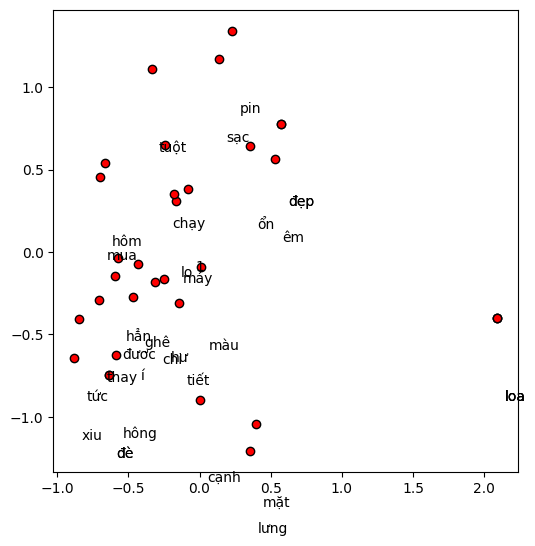

In [22]:
sentence = '''tất_cả mọi thứ ổn hết màn_hình đẹp máy chạy êm pin sạc nhanh màu mặt lưng đẹp tiết ở phần thiết_kế chi loa ngoài đặt ở bên hông thay đặt ở cạnh tay đè loa sử_dụng í lo chính bản_thân đè quá làm loa hư thêm 1 nhỏ_xíu xiu mới mua hôm giảm 500000đ nay xem tuột xuống đươc giảm hẳn 1000000đ tức ghê'''

sentence = sentence.lower()
sentence = cleandt.remove_punctuation(sentence)
sentence = ViTokenizer.tokenize(sentence)
sentence = cleandt.remove_stopword(sentence, '../data/data_stopword/vietnamese-stopwords-dash.txt')
words = sentence.split()

words_scatterplot(model, words)

* The relationships among documents

In [23]:
temp_embeddings = pemb.post_embedding(input_gensim, 100)
mean_temp_embedding = mvectorize.mean_posts_embedding(temp_embeddings)

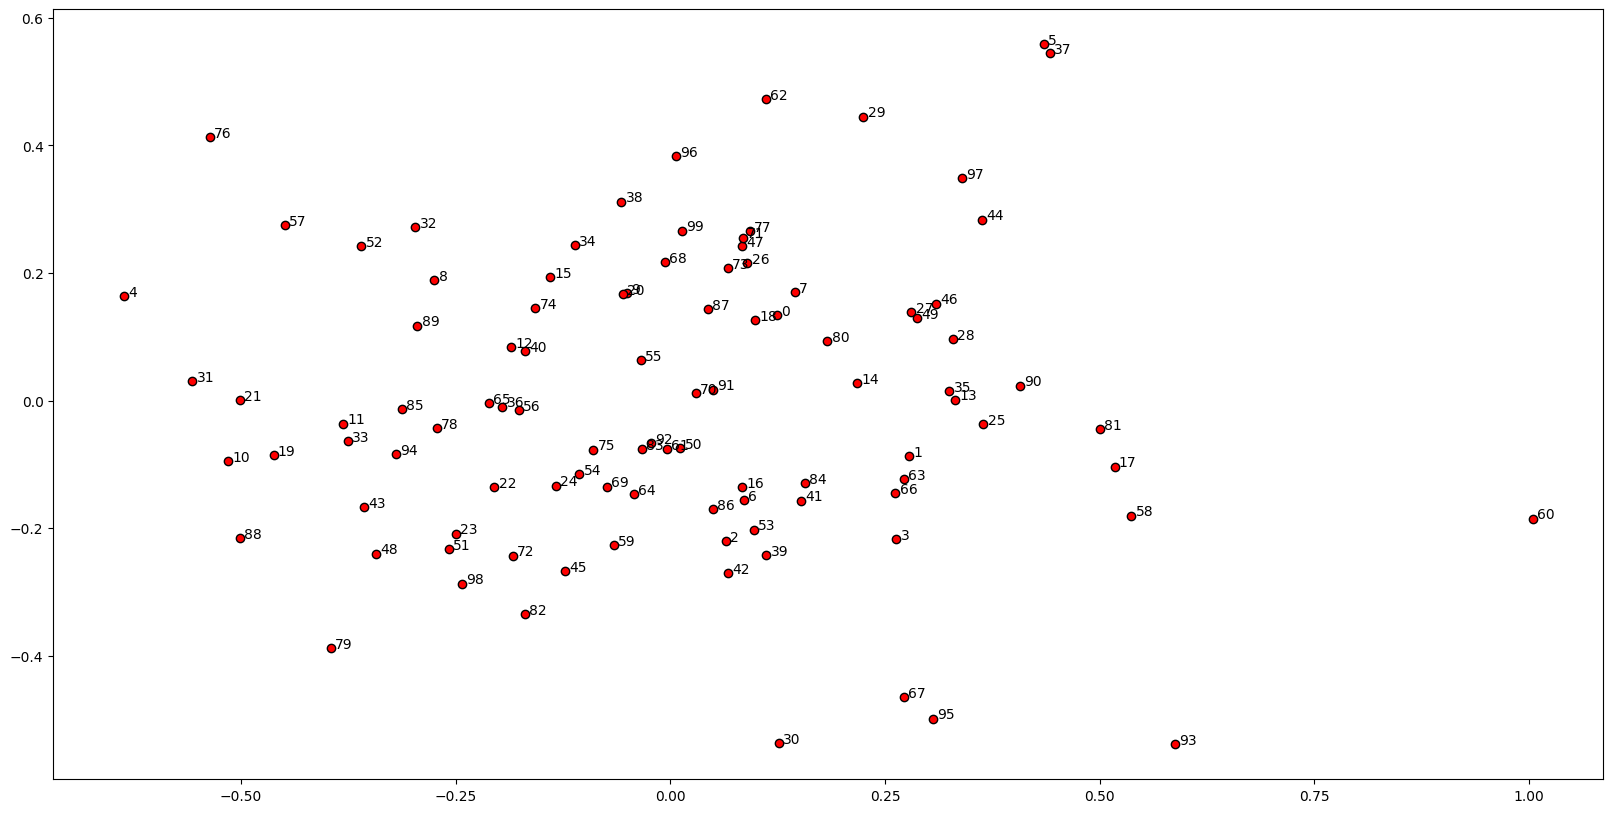

In [24]:
# mean_post_embedding
post_vectors = []
for post_embedding in mean_temp_embedding:
    post_vectors.append(post_embedding.tolist())

twodim = PCA().fit_transform(post_vectors)[:,:2]
index = [i for i,_ in enumerate(mean_temp_embedding)]

plt.figure(figsize=(20,10))
plt.scatter(twodim[:,0], twodim[:,1], edgecolors='k', c='r')
for doc, (x,y) in zip(index, twodim):
    plt.text(x+0.005, y, doc)

## Text clustering with Kmean algorithm

In [25]:
# Tạo các embedding cho dữ liệu
text_embeddings = pemb.post_embedding(input_gensim)
    
print(len(text_embeddings))
print(len(text_embeddings[0]))

8898
14


In [26]:
# Tính toán mean embedding
mean_text_embeddings = mvectorize.flatten_mean_embedding(text_embeddings)
print(len(mean_text_embeddings))

100%|██████████| 8898/8898 [00:00<00:00, 22090.53it/s]

8898


In [27]:
# Đệm thêm 0 để đủ độ dài trong từng văn bản
max_length = max([len(i) for i in mean_text_embeddings])
mean_text_embeddings_padding = np.array(preprocessing.sequence.pad_sequences(mean_text_embeddings, maxlen=max_length, padding='pre', dtype='float32'))

In [28]:
from clusteval import clusteval
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import numpy as np

In [29]:
print("The shape of padding sequences array:", mean_text_embeddings_padding.shape)
print(mean_text_embeddings_padding[0:5])

The shape of padding sequences array: (8898, 129)
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000

In [30]:
# Set parameters, as an example dbscan
ce = clusteval(evaluate='silhouette', max_clust=20, normalize=True)

# Fit to find optimal number of clusters using dbscan
results = ce.fit(mean_text_embeddings_padding)

[clusteval] >INFO> Normalizing input data per feature (zero mean and unit variance)
[clusteval] >INFO> Saving data in memory.
[clusteval] >INFO> Fit with method=[agglomerative], metric=[euclidean], linkage=[ward]
[clusteval] >INFO> Evaluate using silhouette.
[clusteval] >INFO: 100%|██████████| 18/18 [00:35<00:00,  1.95s/it]
[clusteval] >INFO> Compute dendrogram threshold.
[clusteval] >INFO> Optimal number clusters detected: [2].
[clusteval] >INFO> Fin.


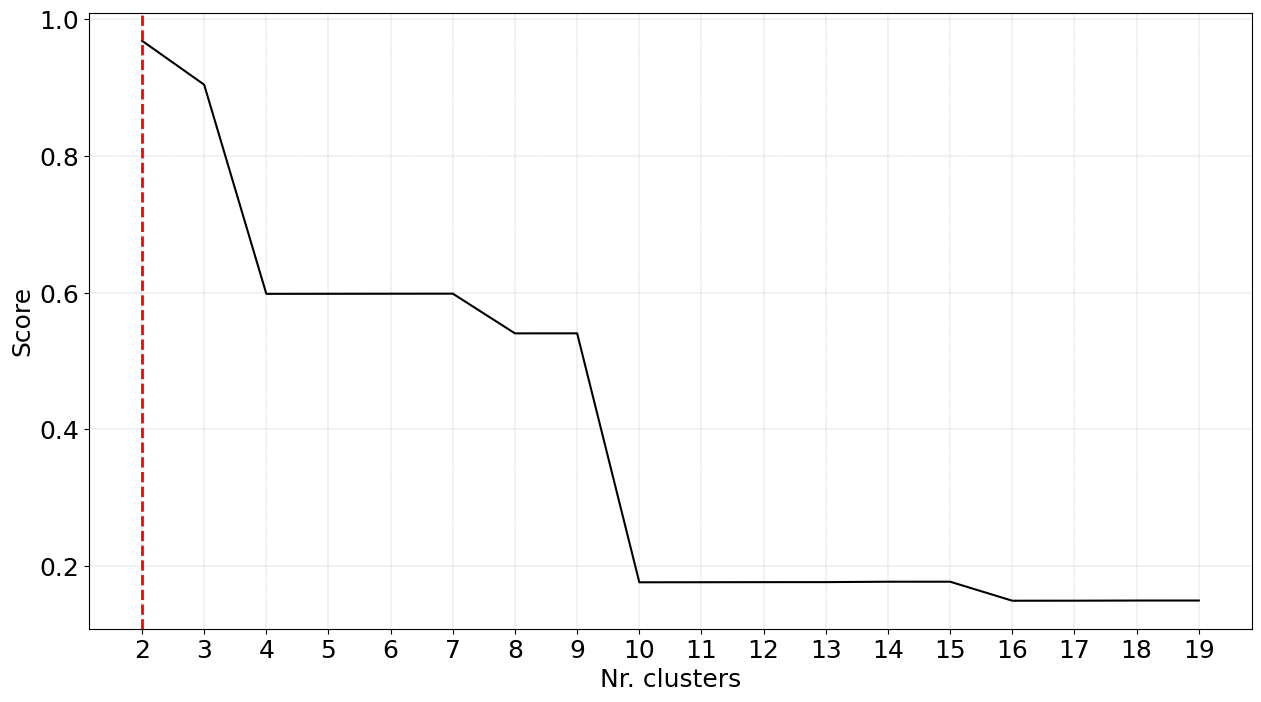

(<Figure size 1500x800 with 1 Axes>,
 <Axes: xlabel='Nr. clusters', ylabel='Score'>)

In [31]:
ce.plot(verbose=0)

c:\Users\dtptr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\dtptr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\dtptr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\dtptr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\clus

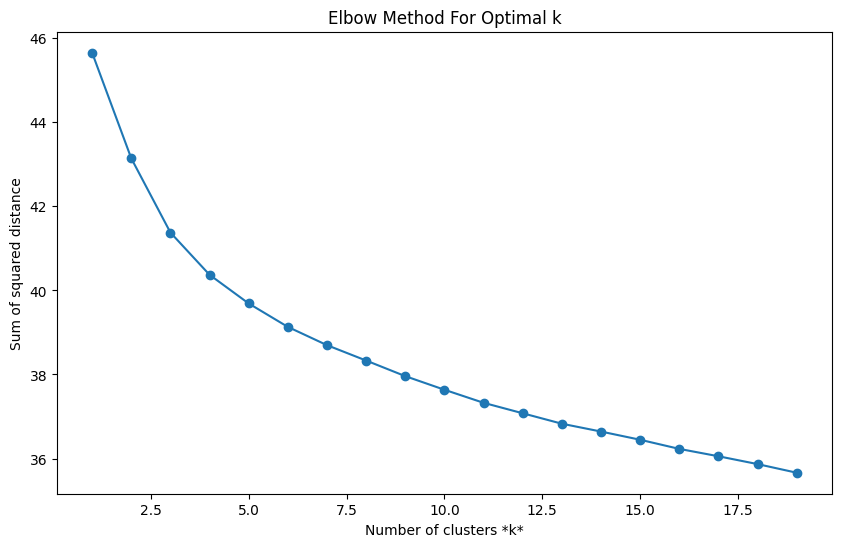

In [32]:
# Run the Kmeans algorithm and get the index of data points clusters
sse = []
list_k = list(range(1, 20))

for k in list_k:
    km = KMeans(n_clusters=k)
    km.fit(mean_text_embeddings_padding)
    sse.append(km.inertia_)

# Plot sse against k
plt.figure(figsize=(10, 6))
plt.plot(list_k, sse, '-o')
plt.xlabel(r'Number of clusters *k*')
plt.ylabel('Sum of squared distance')
plt.title('Elbow Method For Optimal k')
plt.show()


c:\Users\dtptr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Initialization complete
Iteration 0, inertia 73.55940246582031.
Iteration 1, inertia 43.5457763671875.
Iteration 2, inertia 42.762962341308594.
Iteration 3, inertia 42.24566650390625.
Iteration 4, inertia 41.82948684692383.
Iteration 5, inertia 41.565391540527344.
Iteration 6, inertia 41.45823669433594.
Iteration 7, inertia 41.412845611572266.
Iteration 8, inertia 41.39435958862305.
Iteration 9, inertia 41.385921478271484.
Iteration 10, inertia 41.38263702392578.
Iteration 11, inertia 41.380462646484375.
Iteration 12, inertia 41.37873077392578.
Iteration 13, inertia 41.377967834472656.
Iteration 14, inertia 41.37753677368164.
Iteration 15, inertia 41.37712860107422.
Iteration 16, inertia 41.37692642211914.
Iteration 17, inertia 41.37678527832031.
Iteration 18, inertia 41.37677764892578.
Converged at iteration 18: center shift 3.479690091623411e-09 within tolerance 3.977300366386772e-09.
Initialization complete
Iteration 0, inertia 63.52760696411133.
Iteration 1, inertia 42.838100433349

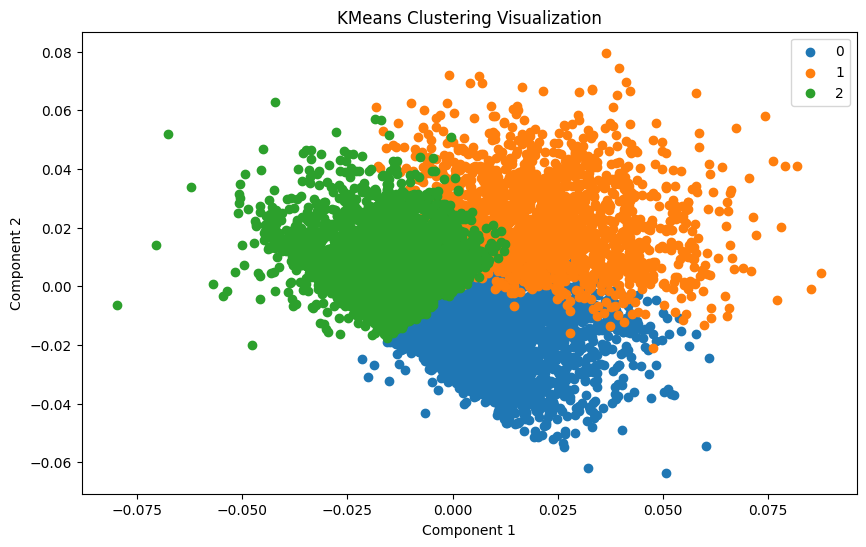

In [33]:
# Giả sử số lượng cụm tối ưu là 3 từ biểu đồ Elbow
kmeans = KMeans(n_clusters=3, verbose=1).fit(mean_text_embeddings_padding)
text_clustering = kmeans.predict(mean_text_embeddings_padding)

# Giảm chiều dữ liệu xuống 2D để trực quan hóa
embedding_2d = PCA(n_components=2).fit_transform(mean_text_embeddings_padding)
temp = np.append(embedding_2d, text_clustering.reshape((len(text_clustering), 1)), axis=1)
df = pd.DataFrame(temp, columns=['Component 1', 'Component 2', 'Cluster'])

# Trực quan hóa kết quả phân cụm
u_labels = np.unique(text_clustering)
plt.figure(figsize=(10, 6))
for i in u_labels:
    plt.scatter(df[df['Cluster'] == i]['Component 1'], df[df['Cluster'] == i]['Component 2'], label=i)
plt.legend()
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('KMeans Clustering Visualization')
plt.show()


In [34]:
# Gắn nhãn cho dữ liệu gốc
clustered_news = news.copy()
clustered_news['Cluster'] = text_clustering

# Đặt tên các cụm theo thứ tự: Positive, Negative, Neutral
cluster_names = {0: 'Positive', 1: 'Negative', 2: 'Neutral'}
clustered_news['Cluster Name'] = clustered_news['Cluster'].map(cluster_names)

# Hiển thị một số dòng dữ liệu với nhãn cụm và tên cụm
clustered_news.head(10)


,comment,n_star,date_time,Cluster,Cluster Name
0,pin kém còn miễn chê mua 832019 tình_trạng pin...,5,14/09/2019,2,Neutral
1,sao gọi điện_thoại màn_hình chấm nhỏ nháy gần ...,3,17/08/2020,0,Positive
2,mọi người cập_nhật phần_mềm nó bớt tốn pin mìn...,3,29/02/2020,2,Neutral
3,mới mua sài 1 tháng thấy pin trâu sài bao mượt...,5,4/6/2020,1,Negative
4,xài tốt mượt pin trâu bạn độ sáng đủ nhân_viên...,5,20/06/2019,0,Positive
5,hôm ngày 2362020 e thế_giới di_động mua dthoai...,2,23/06/2020,2,Neutral
6,sao điện_thoại mới sạc nó nóng máy quá trời t_...,2,23/12/2019,1,Negative
7,đầu định mua samsung shop nhân_viên tư_vấn opp...,1,31/05/2020,2,Neutral
8,mọi thứ ngon trong tầm giá lần đầu xài xiaomi ...,5,30/05/2020,0,Positive
9,đi thoại mượt chơi game ngon âm báo_thức bật m...,4,7/6/2019,2,Neutral


In [35]:
# Drop cột Cluster
clustered_news = clustered_news.drop(columns=['Cluster'])

# Đổi tên cột Cluster Name thành label
clustered_news = clustered_news.rename(columns={'Cluster Name': 'label'})

# Gán dataframe mới cho biến trainprocess_kmeans
trainprocess_kmeans = clustered_news.copy()

# Hiển thị một số dòng dữ liệu của dataframe mới
trainprocess_kmeans.head()
 

,comment,n_star,date_time,label
0,pin kém còn miễn chê mua 832019 tình_trạng pin...,5,14/09/2019,Neutral
1,sao gọi điện_thoại màn_hình chấm nhỏ nháy gần ...,3,17/08/2020,Positive
2,mọi người cập_nhật phần_mềm nó bớt tốn pin mìn...,3,29/02/2020,Neutral
3,mới mua sài 1 tháng thấy pin trâu sài bao mượt...,5,4/6/2020,Negative
4,xài tốt mượt pin trâu bạn độ sáng đủ nhân_viên...,5,20/06/2019,Positive
